# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age
* Fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



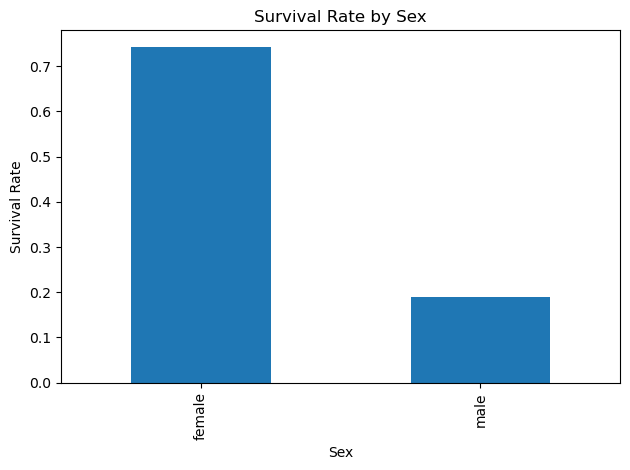

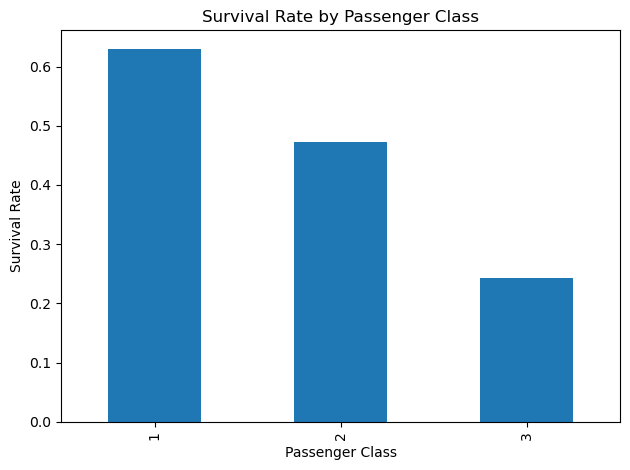

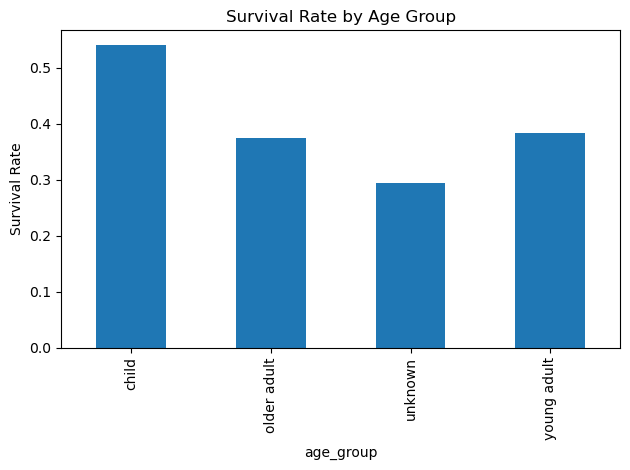

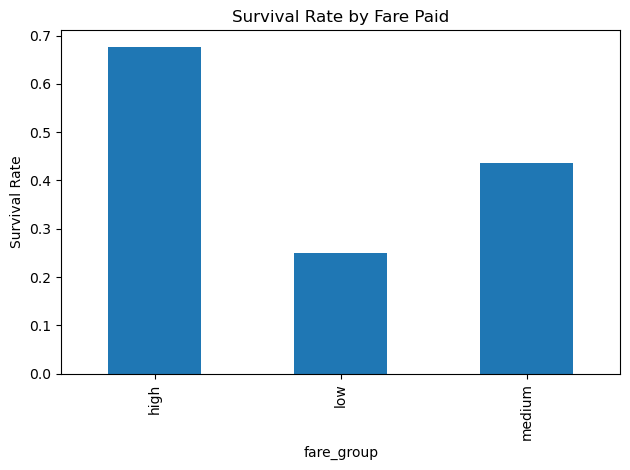

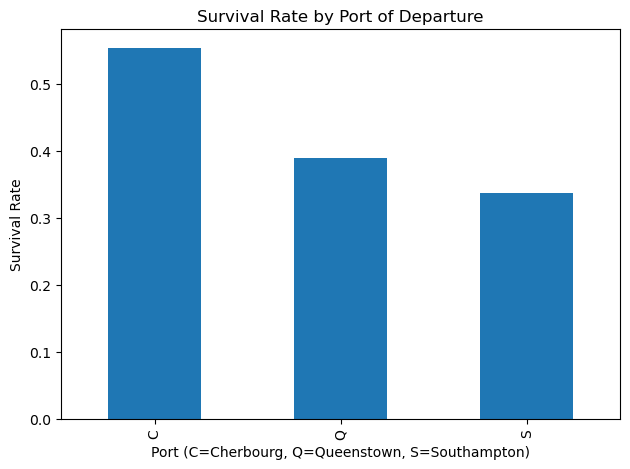

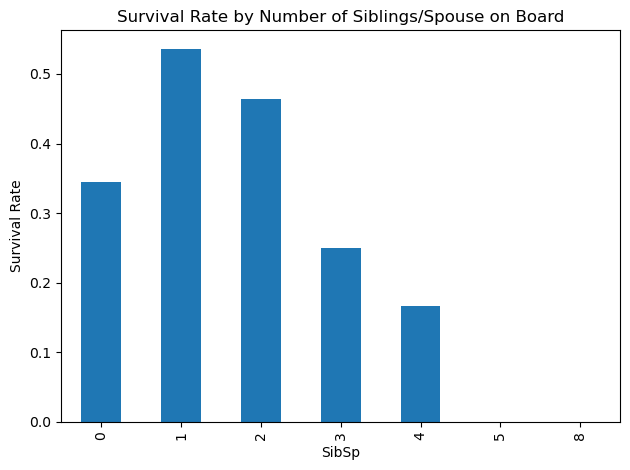

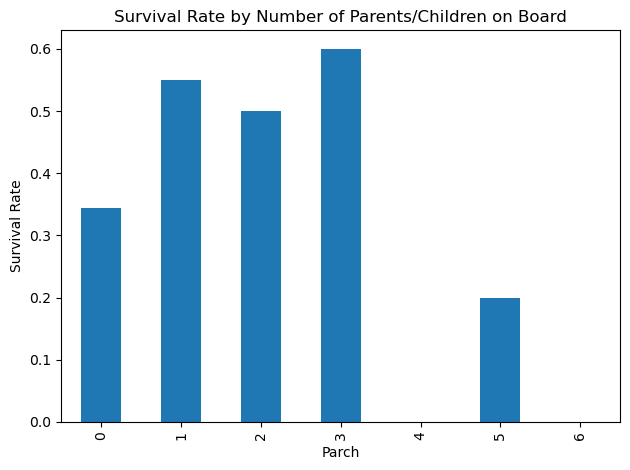

                                                  Name   Age      Fare  SibSp  \
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0   71.2833      1   
215                            Newell, Miss. Madeleine  31.0  113.2750      1   
218                              Bazzani, Miss. Albina  32.0   76.2917      0   

     Parch Embarked  
1        0        C  
215      0        C  
218      0        C  
                              Name   Age  Fare  SibSp  Parch Embarked
0          Braund, Mr. Owen Harris  22.0  7.25      1      0        S
4         Allen, Mr. William Henry  35.0  8.05      0      0        S
12  Saundercock, Mr. William Henry  20.0  8.05      0      0        S


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('titanic_passengers.csv')

df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

df.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')
plt.tight_layout()
plt.show()

df['age_group'] = 'unknown'
df.loc[df['Age'] < 18, 'age_group'] = 'child'
df.loc[(df['Age'] >= 18) & (df['Age'] < 40), 'age_group'] = 'young adult'
df.loc[df['Age'] >= 40, 'age_group'] = 'older adult'

df.groupby('age_group')['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Age Group')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

df['fare_group'] = 'unknown'
df.loc[df['Fare'] < 15, 'fare_group'] = 'low'
df.loc[(df['Fare'] >= 15) & (df['Fare'] < 50), 'fare_group'] = 'medium'
df.loc[df['Fare'] >= 50, 'fare_group'] = 'high'

df.groupby('fare_group')['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Fare Paid')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

df.groupby('Embarked')['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Port of Departure')
plt.ylabel('Survival Rate')
plt.xlabel('Port (C=Cherbourg, Q=Queenstown, S=Southampton)')
plt.tight_layout()
plt.show()

df.groupby('SibSp')['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Number of Siblings/Spouse on Board')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

df.groupby('Parch')['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Number of Parents/Children on Board')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

most_likely = df[
    (df['Sex'] == 'female') &
    (df['Pclass'] == 1) &
    (df['age_group'] == 'young adult') &
    (df['fare_group'] == 'high') &
    (df['Embarked'] == 'C') &
    (df['Survived'] == 1)
]
print(most_likely[['Name', 'Age', 'Fare', 'SibSp', 'Parch', 'Embarked']].head(3))

least_likely = df[
    (df['Sex'] == 'male') &
    (df['Pclass'] == 3) &
    (df['age_group'] == 'young adult') &
    (df['fare_group'] == 'low') &
    (df['Embarked'] == 'S') &
    (df['Survived'] == 0)
]
print(least_likely[['Name', 'Age', 'Fare', 'SibSp', 'Parch', 'Embarked']].head(3))
